In [1]:
# IMPORTS

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader

import copy
import itertools

In [2]:
file_path = "dataset_ovarian_cancer.txt"

df = pd.read_csv(
    file_path,
    sep="\t",
    skiprows=5
)

# Remove benign and borderline samples
df = df[~df["Diagnosis"].isin(["benign", "borderline"])].copy()

print(df.head())
print()
print("Shape:", df.shape)
print()
print("Columns:")
print(df.columns)

  Sample-ID  Replicate      PROK1        WFDC2        KRT19     FR-alpha  \
0      id_1          1   51.27954   2684.67462  814977.3242    978.62687   
1      id_1          2   61.33529   2837.46526  896027.9581   1105.94503   
6      id_4          1   64.48318  17540.11449  20619803.29   3470.07213   
7      id_4          2   69.73640  16819.42076  18572286.48   3369.12071   
8      id_5          1  102.80136  47140.90177  1965477.203  33382.84010   

        ICOSLG         CDH3        MSMB    CLEC6A     TACSTD2       MUC-16  \
0   4962.66112  38555.25779  4923.13477  15.18093   160.80636  16652.85209   
1   5416.43019  39359.37085  4895.63176  14.14949   161.81711  17377.84122   
6   4673.40098  46314.54069  6192.18559  13.72160   401.55326       > ULOQ   
7   4424.60677  49723.35415  5950.36607  13.59799   419.70932       > ULOQ   
8  11875.94962  70572.30654  4343.25094  28.61630  1803.12287       > ULOQ   

        SPINT1  AgeAtDiag Diagnosis  
0   9610.23806         49         I 

In [3]:
features = [
    "PROK1",
    "WFDC2",
    "KRT19",
    "FR-alpha",
    "ICOSLG",
    "CDH3",
    "MSMB",
    "CLEC6A",
    "TACSTD2",
    "MUC-16",
    "SPINT1",
    "AgeAtDiag"
]

target = "Diagnosis"

uloq = {
    "PROK1": 16883.06305,
    "WFDC2": 181210.6285,
    "KRT19": 68900244.48,
    "FR-alpha": 163421.4035,
    "ICOSLG": 55648.31473,
    "CDH3": 638185.7656,
    "MSMB": 177291.4083,
    "CLEC6A": 13291.04962,
    "TACSTD2": 33922.31855,
    "MUC-16": 2288168.669,
    "SPINT1": 193069.9522
}

for feature in uloq:
    df[feature] = df[feature].replace(
        "> ULOQ",
        uloq[feature]
    )

    df[feature] = pd.to_numeric(
        df[feature],
        errors="coerce"
    )

print("Missing values:")
print(df[features].isna().sum())

Missing values:
PROK1        4
WFDC2        4
KRT19        4
FR-alpha     4
ICOSLG       4
CDH3         4
MSMB         4
CLEC6A       4
TACSTD2      4
MUC-16       4
SPINT1       4
AgeAtDiag    0
dtype: int64


In [4]:
df_patient = (
    df.groupby("Sample-ID")
      .agg({
          **{feature: "mean" for feature in features},
          "Diagnosis": "first"
      })
      .reset_index()
)

print("Patient-level dataset:")
print(df_patient.head())

print()
print("Shape:", df_patient.shape)

Patient-level dataset:
  Sample-ID      PROK1        WFDC2         KRT19     FR-alpha       ICOSLG  \
0      id_1  56.307415  2761.069940  8.555026e+05  1042.285950  5189.545655   
1     id_10  60.051290  2692.821970  7.599913e+05   911.213855  5974.368245   
2    id_105  59.653160  3827.338373  5.231513e+06  1045.533663  4581.916750   
3    id_106  64.261070  6142.683357  1.277974e+06  1965.823370  5385.793827   
4    id_111  80.136683  9746.318057  2.676830e+06  2918.588623  5287.917977   

           CDH3         MSMB     CLEC6A     TACSTD2         MUC-16  \
0  38957.314320  4909.383265  14.665210  161.311735   17015.346655   
1  28535.242535  1702.930035   9.942800  192.346485    3963.833860   
2  40000.848533  5791.367120  12.804823  453.801403  773309.319100   
3  43192.315020  6375.488787  11.624357  216.743243  696577.633900   
4  57110.993503  7675.507700  11.965677  144.621597  161804.189800   

         SPINT1  AgeAtDiag Diagnosis  
0   9234.424980       49.0         I  
1  

In [5]:
X = df_patient[features].copy()
y = df_patient[target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

label_encoder = LabelEncoder()

y_encoded = label_encoder.fit_transform(y)

print("Classes:")
print(label_encoder.classes_)

X shape: (90, 12)
y shape: (90,)
Classes:
['I' 'II' 'III' 'IV']


In [6]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y_encoded,
    test_size=0.30,
    random_state=42,
    stratify=y_encoded
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Test:", X_test.shape)

Training: (63, 12)
Validation: (13, 12)
Test: (14, 12)


In [7]:
imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)

X_val = imputer.transform(X_val)

X_test = imputer.transform(X_test)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_val = scaler.transform(X_val)

X_test = scaler.transform(X_test)

In [8]:
X_train_tensor = torch.tensor(
    X_train,
    dtype=torch.float32
)

X_val_tensor = torch.tensor(
    X_val,
    dtype=torch.float32
)

X_test_tensor = torch.tensor(
    X_test,
    dtype=torch.float32
)

y_train_tensor = torch.tensor(
    y_train,
    dtype=torch.long
)

y_val_tensor = torch.tensor(
    y_val,
    dtype=torch.long
)

y_test_tensor = torch.tensor(
    y_test,
    dtype=torch.long
)

In [9]:
batch_size = 16

train_dataset = TensorDataset(
    X_train_tensor,
    y_train_tensor
)

val_dataset = TensorDataset(
    X_val_tensor,
    y_val_tensor
)

test_dataset = TensorDataset(
    X_test_tensor,
    y_test_tensor
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

In [10]:
print("Train:", X_train_tensor.shape)
print("Validation:", X_val_tensor.shape)
print("Test:", X_test_tensor.shape)

print()

print("Example X:")
print(X_train_tensor[0])

print()

print("Example y:")
print(y_train_tensor[0])

print()

print("Classes:")
print(label_encoder.classes_)

counts = np.bincount(y_encoded)
for cls, n in zip(label_encoder.classes_, counts):
    print(cls, n)

Train: torch.Size([63, 12])
Validation: torch.Size([13, 12])
Test: torch.Size([14, 12])

Example X:
tensor([-0.6848, -0.7972, -0.6668, -0.4354,  0.3338, -0.4306,  1.2219, -1.1478,
        -0.5244, -1.0426, -0.5526,  1.7391])

Example y:
tensor(3)

Classes:
['I' 'II' 'III' 'IV']
I 14
II 11
III 40
IV 25


In [11]:
# ONN OPERATOR LIBRARIES

# NODAL

def clamp(x, limit):
    return torch.clamp(x, -limit, limit)

NODAL_OPERATORS = {

    "linear":
        lambda x: x,

    "quadratic":
        lambda x: torch.sign(x) * clamp(x, 4.0) ** 2,

    #"cubic":
        #lambda x: clamp(x, 3.0) ** 3,

    #"sinusoidal":
        #lambda x: torch.sin(x),

    "tanh":
        lambda x: torch.tanh(x),

    "gaussian":
        lambda x: torch.exp(-clamp(x, 4.0) ** 2)

    #"dog":
        #lambda x: clamp(x, 4.0) *
                  #torch.exp(-clamp(x, 4.0) ** 2),

    #"exponential":
        #lambda x: torch.sign(x) *
                  #(torch.exp(clamp(torch.abs(x), 4.0)) - 1.0)
}

# POOLING

def pool_sum(x):
    return x.sum(dim=2)


def pool_mean(x):
    return x.mean(dim=2)


def pool_max(x):
    return x.max(dim=2).values


def pool_min(x):
    return x.min(dim=2).values


def pool_l2(x):
    return torch.sqrt(
        torch.sum(x ** 2, dim=2) + 1e-8
    )

POOLING_OPERATORS = {

    "sum": pool_sum,

    "mean": pool_mean,

    "max": pool_max,

    "min": pool_min,

    "l2": pool_l2
}

In [12]:
# OPERATIONAL LAYER

class OperationalLayer(nn.Module):

    def __init__(
        self,
        in_features,
        out_features,
        nodal_operator="linear",
        pooling_operator="sum"
    ):

        super().__init__()

        self.in_features = in_features
        self.out_features = out_features

        self.nodal_operator_name = nodal_operator
        self.pooling_operator_name = pooling_operator

        # Weight for every connection
        self.weight = nn.Parameter(
            torch.randn(out_features, in_features)
            * np.sqrt(2.0 / in_features)
        )

        self.bias = nn.Parameter(
            torch.zeros(out_features)
        )

    def forward(self, x):

        z = (
            x.unsqueeze(1)
            * self.weight.unsqueeze(0)
        )

        # NODAL

        nodal_operator = NODAL_OPERATORS[
            self.nodal_operator_name
        ]

        z = nodal_operator(z)

        # POOLING

        pooling_operator = POOLING_OPERATORS[
            self.pooling_operator_name
        ]

        y = pooling_operator(z)

        # BIAS

        y = y + self.bias

        return y

In [13]:
# RESIDUAL ONN BLOCK

class ResidualONNBlock(nn.Module):

    def __init__(
        self,
        in_features,
        out_features,
        nodal_operator="linear",
        pooling_operator="sum",
        dropout=0.15
    ):

        super().__init__()

        # Main ONN path
        self.onn = OperationalLayer(
            in_features=in_features,
            out_features=out_features,
            nodal_operator=nodal_operator,
            pooling_operator=pooling_operator
        )

        # Projection for the residual connection
        if in_features == out_features:
            self.shortcut = nn.Identity()
        else:
            self.shortcut = nn.Linear(
                in_features,
                out_features,
                bias=False
            )

        self.norm = nn.LayerNorm(out_features)

        self.dropout = nn.Dropout(dropout)

        self.activation = nn.ReLU()

    def forward(self, x):

        # Main path
        out = self.onn(x)

        # Residual path
        residual = self.shortcut(x)

        # Add them
        out = out + residual

        # Normalize
        out = self.norm(out)

        # Activation
        out = self.activation(out)

        # Dropout
        out = self.dropout(out)

        return out

In [14]:
# ONN MODEL

class ONN(nn.Module):

    def __init__(
        self,
        input_size,
        num_classes,
        hidden_sizes=(32, 16),
        nodal_operators=("linear", "linear"),
        pooling_operators=("sum", "sum"),
        dropout=0.15
    ):

        super().__init__()

        assert len(nodal_operators) == len(hidden_sizes)
        assert len(pooling_operators) == len(hidden_sizes)

        dims = [
            input_size,
            *hidden_sizes
        ]

        self.hidden_layers = nn.ModuleList()

        # HIDDEN RESIDUAL ONN BLOCKS

        for i in range(len(hidden_sizes)):

            layer = ResidualONNBlock(
                in_features=dims[i],
                out_features=dims[i + 1],
                nodal_operator=nodal_operators[i],
                pooling_operator=pooling_operators[i],
                dropout=dropout
            )

            self.hidden_layers.append(layer)

        # CLASSIFICATION HEAD

        self.output_layer = nn.Linear(
            dims[-1],
            num_classes
        )

    def forward(self, x):

        for layer in self.hidden_layers:

            x = layer(x)

        x = self.output_layer(x)

        return x

In [15]:
# ============================================================
# TRAIN ONE ONN CONFIGURATION
# ============================================================

def train_eval_onn(
    nodal_operators,
    pooling_operators,
    input_size,
    num_classes,
    train_loader,
    val_loader,
    device,
    epochs=60,
    learning_rate=0.001,
    weight_decay=1e-4,
    hidden_sizes=(32, 16),
    dropout=0.2
):

    model = ONN(
        input_size=input_size,
        num_classes=num_classes,
        hidden_sizes=hidden_sizes,
        nodal_operators=nodal_operators,
        pooling_operators=pooling_operators,
        dropout=dropout
    ).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )

    best_val_accuracy = 0.0
    best_state = None

    for epoch in range(epochs):

        # ====================================================
        # TRAIN
        # ====================================================

        model.train()

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            outputs = model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            loss.backward()

            optimizer.step()

        # ====================================================
        # VALIDATION
        # ====================================================

        model.eval()

        correct = 0
        total = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                outputs = model(X_batch)

                predictions = outputs.argmax(dim=1)

                correct += (
                    predictions == y_batch
                ).sum().item()

                total += y_batch.size(0)

        val_accuracy = correct / total

        # ----------------------------------------------------
        # SAVE BEST MODEL
        # ----------------------------------------------------

        if val_accuracy > best_val_accuracy:

            best_val_accuracy = val_accuracy

            best_state = copy.deepcopy(
                model.state_dict()
            )

    # Restore best validation model

    if best_state is not None:

        model.load_state_dict(best_state)

    return model, best_val_accuracy

In [16]:
# ============================================================
# GIS
# GREEDY OPERATOR SELECTION
# ============================================================

def GIS(
    input_size,
    num_classes,
    train_loader,
    val_loader,
    device,
    hidden_sizes=(32, 16),
    epochs=60,
    dropout=0.2
):

    selected_nodal = []
    selected_pooling = []

    num_layers = len(hidden_sizes)

    print("=" * 60)
    print("STARTING GIS")
    print("=" * 60)

    # --------------------------------------------------------
    # Search one layer at a time
    # --------------------------------------------------------

    for layer_idx in range(num_layers):

        print()
        print(
            f"Searching layer "
            f"{layer_idx + 1}/{num_layers}"
        )

        best_score = -float("inf")

        best_nodal = None
        best_pooling = None

        # ----------------------------------------------------
        # Try every nodal + pooling combination
        # ----------------------------------------------------

        for nodal_name in NODAL_OPERATORS.keys():

            for pooling_name in POOLING_OPERATORS.keys():

                # Operators already selected for previous layers
                trial_nodal = selected_nodal + [
                    nodal_name
                ]

                trial_pooling = selected_pooling + [
                    pooling_name
                ]

                # ------------------------------------------------
                # Remaining layers use linear + sum
                # ------------------------------------------------

                while len(trial_nodal) < num_layers:

                    trial_nodal.append("linear")
                    trial_pooling.append("sum")

                print(
                    f"Testing: "
                    f"Layer {layer_idx + 1} → "
                    f"nodal={nodal_name}, "
                    f"pooling={pooling_name}"
                )

                model, val_accuracy = train_eval_onn(
                    nodal_operators=trial_nodal,
                    pooling_operators=trial_pooling,
                    input_size=input_size,
                    num_classes=num_classes,
                    train_loader=train_loader,
                    val_loader=val_loader,
                    device=device,
                    epochs=epochs,
                    hidden_sizes=hidden_sizes,
                    dropout=dropout
                )

                print(
                    f"Validation accuracy: "
                    f"{val_accuracy:.4f}"
                )

                # ------------------------------------------------
                # Keep best combination
                # ------------------------------------------------

                if val_accuracy > best_score:

                    best_score = val_accuracy

                    best_nodal = nodal_name
                    best_pooling = pooling_name

        # ----------------------------------------------------
        # Permanently select best operators for this layer
        # ----------------------------------------------------

        selected_nodal.append(best_nodal)
        selected_pooling.append(best_pooling)

        print()
        print(
            f"BEST FOR LAYER {layer_idx + 1}:"
        )

        print(
            f"  Nodal   = {best_nodal}"
        )

        print(
            f"  Pooling = {best_pooling}"
        )

        print(
            f"  Validation accuracy = "
            f"{best_score:.4f}"
        )

    # --------------------------------------------------------
    # Final architecture
    # --------------------------------------------------------

    print()
    print("=" * 60)
    print("GIS RESULT")
    print("=" * 60)

    for i in range(num_layers):

        print(
            f"Layer {i + 1}: "
            f"nodal={selected_nodal[i]}, "
            f"pooling={selected_pooling[i]}"
        )

    return selected_nodal, selected_pooling

In [17]:
# ============================================================
# DEVICE
# ============================================================

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

input_size = len(features)
num_classes = len(label_encoder.classes_)

# ============================================================
# RUN GIS
# ============================================================

selected_nodal, selected_pooling = GIS(
    input_size=input_size,
    num_classes=num_classes,
    train_loader=train_loader,
    val_loader=val_loader,
    device=device,

    # Smaller network is preferable for your dataset
    hidden_sizes=(32, 16),

    # GIS training epochs
    epochs=60,

    dropout=0.2
)



Device: cpu
STARTING GIS

Searching layer 1/2
Testing: Layer 1 → nodal=linear, pooling=sum
Validation accuracy: 0.5385
Testing: Layer 1 → nodal=linear, pooling=mean
Validation accuracy: 0.5385
Testing: Layer 1 → nodal=linear, pooling=max
Validation accuracy: 0.5385
Testing: Layer 1 → nodal=linear, pooling=min
Validation accuracy: 0.6154
Testing: Layer 1 → nodal=linear, pooling=l2
Validation accuracy: 0.5385
Testing: Layer 1 → nodal=quadratic, pooling=sum
Validation accuracy: 0.3846
Testing: Layer 1 → nodal=quadratic, pooling=mean
Validation accuracy: 0.4615
Testing: Layer 1 → nodal=quadratic, pooling=max
Validation accuracy: 0.5385
Testing: Layer 1 → nodal=quadratic, pooling=min
Validation accuracy: 0.5385
Testing: Layer 1 → nodal=quadratic, pooling=l2
Validation accuracy: 0.7692
Testing: Layer 1 → nodal=tanh, pooling=sum
Validation accuracy: 0.4615
Testing: Layer 1 → nodal=tanh, pooling=mean
Validation accuracy: 0.5385
Testing: Layer 1 → nodal=tanh, pooling=max
Validation accuracy: 0.

In [18]:
# ============================================================
# FINAL GIS-SELECTED ONN
# ============================================================

onn_model = ONN(
    input_size=input_size,
    num_classes=num_classes,

    hidden_sizes=(32, 16),

    nodal_operators=selected_nodal,

    pooling_operators=selected_pooling,

    dropout=0.2
).to(device)

print(onn_model)

ONN(
  (hidden_layers): ModuleList(
    (0): ResidualONNBlock(
      (onn): OperationalLayer()
      (shortcut): Linear(in_features=12, out_features=32, bias=False)
      (norm): LayerNorm((32,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.2, inplace=False)
      (activation): ReLU()
    )
    (1): ResidualONNBlock(
      (onn): OperationalLayer()
      (shortcut): Linear(in_features=32, out_features=16, bias=False)
      (norm): LayerNorm((16,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.2, inplace=False)
      (activation): ReLU()
    )
  )
  (output_layer): Linear(in_features=16, out_features=4, bias=True)
)


In [19]:
# ============================================================
# FINAL ONN TRAINING
# ============================================================

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.AdamW(
    onn_model.parameters(),
    lr=0.001,
    weight_decay=1e-4
)

num_epochs = 100

best_val_accuracy = 0.0

best_model_state = None

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []


for epoch in range(num_epochs):

    # ========================================================
    # TRAIN
    # ========================================================

    onn_model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for X_batch, y_batch in train_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        outputs = onn_model(X_batch)

        loss = criterion(
            outputs,
            y_batch
        )

        loss.backward()

        optimizer.step()

        running_loss += (
            loss.item() *
            X_batch.size(0)
        )

        predictions = outputs.argmax(dim=1)

        correct += (
            predictions == y_batch
        ).sum().item()

        total += y_batch.size(0)

    train_loss = running_loss / total

    train_accuracy = correct / total

    # ========================================================
    # VALIDATION
    # ========================================================

    onn_model.eval()

    val_running_loss = 0.0
    val_correct = 0
    val_total = 0

    with torch.no_grad():

        for X_batch, y_batch in val_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            outputs = onn_model(X_batch)

            loss = criterion(
                outputs,
                y_batch
            )

            val_running_loss += (
                loss.item() *
                X_batch.size(0)
            )

            predictions = outputs.argmax(dim=1)

            val_correct += (
                predictions == y_batch
            ).sum().item()

            val_total += y_batch.size(0)

    val_loss = val_running_loss / val_total

    val_accuracy = val_correct / val_total

    # ========================================================
    # STORE HISTORY
    # ========================================================

    train_losses.append(train_loss)
    val_losses.append(val_loss)

    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)

    # ========================================================
    # SAVE BEST MODEL
    # ========================================================

    if val_accuracy > best_val_accuracy:

        best_val_accuracy = val_accuracy

        best_model_state = copy.deepcopy(
            onn_model.state_dict()
        )

    # ========================================================
    # PRINT
    # ========================================================

    print(
        f"Epoch [{epoch + 1:3d}/{num_epochs}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_accuracy:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_accuracy:.4f}"
    )


# ============================================================
# RESTORE BEST MODEL
# ============================================================

onn_model.load_state_dict(best_model_state)

print()
print(
    f"Best validation accuracy: "
    f"{best_val_accuracy:.4f}"
)

Epoch [  1/100] Train Loss: 1.4197 Train Acc: 0.3333 Val Loss: 1.3118 Val Acc: 0.5385
Epoch [  2/100] Train Loss: 1.3729 Train Acc: 0.3651 Val Loss: 1.2953 Val Acc: 0.4615
Epoch [  3/100] Train Loss: 1.3579 Train Acc: 0.3492 Val Loss: 1.2845 Val Acc: 0.4615
Epoch [  4/100] Train Loss: 1.3703 Train Acc: 0.3651 Val Loss: 1.2727 Val Acc: 0.4615
Epoch [  5/100] Train Loss: 1.3359 Train Acc: 0.4444 Val Loss: 1.2650 Val Acc: 0.4615
Epoch [  6/100] Train Loss: 1.2519 Train Acc: 0.4603 Val Loss: 1.2579 Val Acc: 0.4615
Epoch [  7/100] Train Loss: 1.2819 Train Acc: 0.4127 Val Loss: 1.2523 Val Acc: 0.4615
Epoch [  8/100] Train Loss: 1.2664 Train Acc: 0.4603 Val Loss: 1.2493 Val Acc: 0.4615
Epoch [  9/100] Train Loss: 1.2623 Train Acc: 0.4603 Val Loss: 1.2471 Val Acc: 0.4615
Epoch [ 10/100] Train Loss: 1.2638 Train Acc: 0.4762 Val Loss: 1.2459 Val Acc: 0.4615
Epoch [ 11/100] Train Loss: 1.2673 Train Acc: 0.4762 Val Loss: 1.2437 Val Acc: 0.4615
Epoch [ 12/100] Train Loss: 1.2195 Train Acc: 0.4762 V

Test accuracy: 0.5000

CLASSIFICATION REPORT

              precision    recall  f1-score   support

           I       0.00      0.00      0.00         2
          II       0.00      0.00      0.00         2
         III       0.50      1.00      0.67         6
          IV       0.50      0.25      0.33         4

    accuracy                           0.50        14
   macro avg       0.25      0.31      0.25        14
weighted avg       0.36      0.50      0.38        14


CONFUSION MATRIX

[[0 0 2 0]
 [0 0 1 1]
 [0 0 6 0]
 [0 0 3 1]]


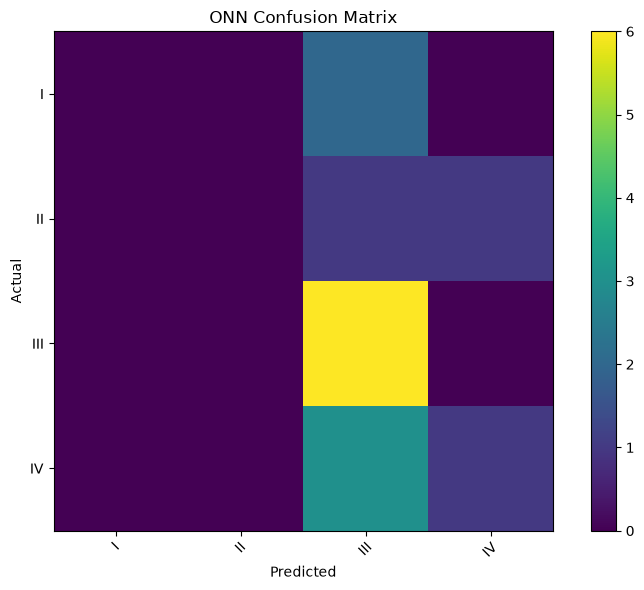

In [20]:
# ============================================================
# TEST SET EVALUATION
# ============================================================

onn_model.eval()

all_predictions = []
all_targets = []

with torch.no_grad():

    for X_batch, y_batch in test_loader:

        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        outputs = onn_model(X_batch)

        predictions = outputs.argmax(dim=1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_targets.extend(
            y_batch.cpu().numpy()
        )


# ============================================================
# TEST ACCURACY
# ============================================================

test_accuracy = (
    np.array(all_predictions) ==
    np.array(all_targets)
).mean()

print(f"Test accuracy: {test_accuracy:.4f}")


# ============================================================
# CLASSIFICATION REPORT
# ============================================================

print("\nCLASSIFICATION REPORT\n")

print(
    classification_report(
        all_targets,
        all_predictions,
        target_names=label_encoder.classes_,
        zero_division=0
    )
)


# ============================================================
# CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    all_targets,
    all_predictions
)

print("\nCONFUSION MATRIX\n")
print(cm)


# ============================================================
# CONFUSION MATRIX PLOT
# ============================================================

plt.figure(figsize=(8, 6))

plt.imshow(cm)

plt.xticks(
    range(num_classes),
    label_encoder.classes_,
    rotation=45
)

plt.yticks(
    range(num_classes),
    label_encoder.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.title("ONN Confusion Matrix")

plt.colorbar()

plt.tight_layout()

plt.show()